In [2]:
pip install opencv-contrib-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\casta\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\casta\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python313\\site-packages\\cv2\\cv2.pyd'
Check the permissions.


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\casta\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import cv2
import os

video_path = "may3_2026.mp4"

if not os.path.exists(video_path):
    raise FileNotFoundError("Video not found.")

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError("Cannot open video.")

print("Video loaded successfully.")

while True:
    ret, frame = cap.read()

    if not ret:
        break

    cv2.imshow("Video", frame)

    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Video loaded successfully.


KeyboardInterrupt: 

__________________________________________________________________________________

In [1]:
import cv2
import numpy as np
import os

# -------------------------
# VIDEO PATH
# -------------------------
video_path = "may3_2026.mp4"

if not os.path.exists(video_path):
    raise FileNotFoundError("Video not found.")

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError("Cannot open video.")

# -------------------------
# READ FIRST FRAME
# -------------------------
ret, frame = cap.read()
if not ret:
    raise RuntimeError("Cannot read first frame.")

# -------------------------
# SELECT OBJECT TO TRACK
# -------------------------
bbox = cv2.selectROI("Select Object", frame, False)
cv2.destroyAllWindows()

x, y, w, h = bbox

# -------------------------
# INITIALIZE TRACKER
# -------------------------
tracker = cv2.TrackerCSRT_create()
tracker.init(frame, bbox)

# -------------------------
# STORE CENTERS FOR MOTION PATH
# -------------------------
centers = []

frame_id = 0

# -------------------------
# TRACK LOOP
# -------------------------
while True:
    ret, frame = cap.read()
    if not ret:
        break

    success, bbox = tracker.update(frame)

    if success:
        x, y, w, h = [int(v) for v in bbox]

        # center point of object
        cx = x + w // 2
        cy = y + h // 2
        centers.append((cx, cy))

        # draw bounding box
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.circle(frame, (cx, cy), 4, (0, 0, 255), -1)

    # draw trajectory
    for i in range(1, len(centers)):
        cv2.line(frame, centers[i - 1], centers[i], (255, 0, 0), 2)

    # -------------------------
    # SIMPLE VELOCITY (PIXELS / FRAME)
    # -------------------------
    if len(centers) > 1:
        dx = centers[-1][0] - centers[-2][0]
        dy = centers[-1][1] - centers[-2][1]
        velocity = np.sqrt(dx**2 + dy**2)
        cv2.putText(frame, f"v ~ {velocity:.2f} px/frame",
                    (20, 40), cv2.FONT_HERSHEY_SIMPLEX,
                    1, (0, 255, 255), 2)

    cv2.imshow("Tracking", frame)

    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

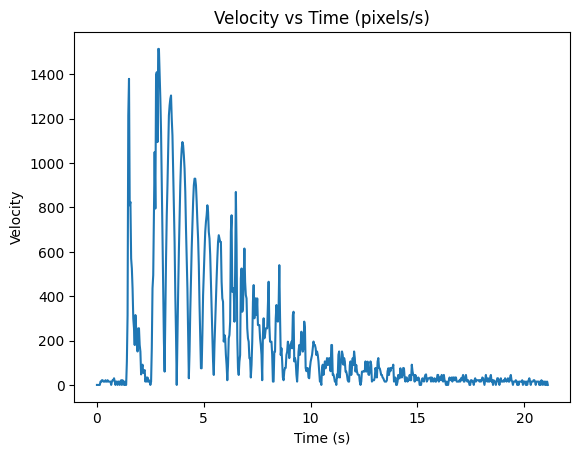

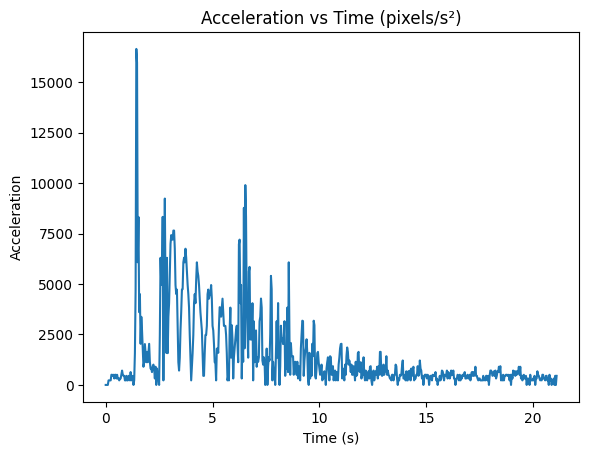

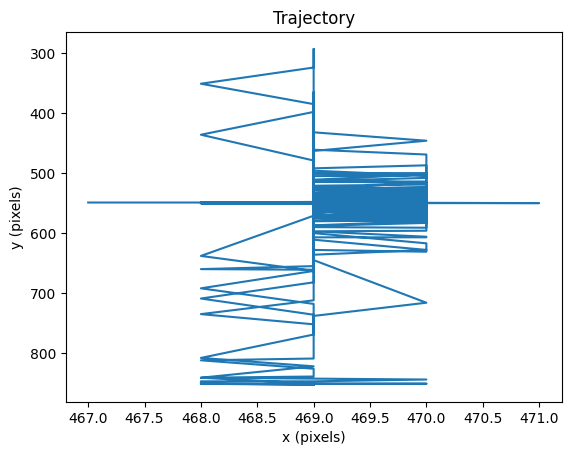

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# YOUR TRACKED DATA
# -------------------------
centers = np.array(centers)

fps = 30  # set correctly
dt = 1 / fps

# -------------------------
# TIME
# -------------------------
t = np.arange(len(centers)) * dt

# -------------------------
# POSITION (PIXELS)
# -------------------------
x = centers[:, 0]
y = centers[:, 1]

# -------------------------
# VELOCITY (PIXELS / s)
# -------------------------
vx = np.gradient(x, dt)
vy = np.gradient(y, dt)

v = np.sqrt(vx**2 + vy**2)

# -------------------------
# ACCELERATION
# -------------------------
ax = np.gradient(vx, dt)
ay = np.gradient(vy, dt)

a = np.sqrt(ax**2 + ay**2)

# -------------------------
# PLOTS
# -------------------------
plt.figure()
plt.plot(t, v)
plt.title("Velocity vs Time (pixels/s)")
plt.xlabel("Time (s)")
plt.ylabel("Velocity")
plt.show()

plt.figure()
plt.plot(t, a)
plt.title("Acceleration vs Time (pixels/s²)")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.show()

plt.figure()
plt.plot(x, y)
plt.title("Trajectory")
plt.xlabel("x (pixels)")
plt.ylabel("y (pixels)")
plt.gca().invert_yaxis()
plt.show()

Spring system parameters
------------------------
Angular frequency ω: 5.648920544309723
Damping γ: -0.0034416713728477786


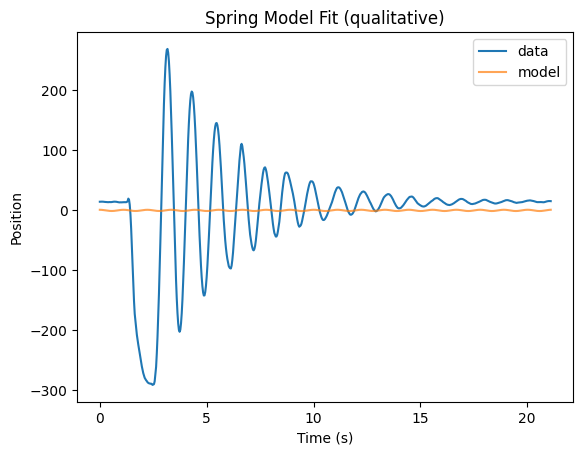

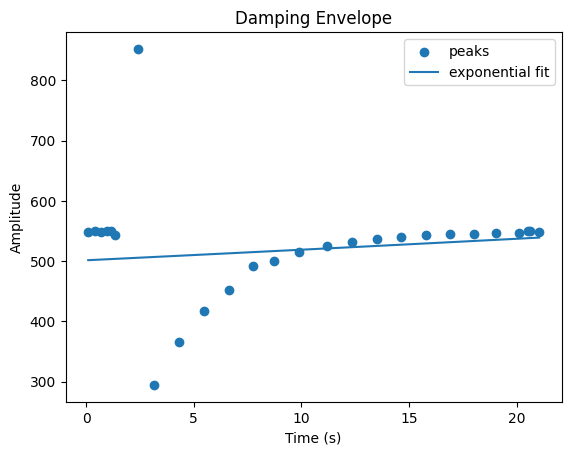

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# -------------------------
# USE YOUR EXISTING DATA
# -------------------------
y = np.array(y)
t = np.array(t)

# invert if needed (image coords)
y = -y

# -------------------------
# SMOOTH SIGNAL (important for noisy tracking)
# -------------------------
y_smooth = savgol_filter(y, window_length=11, polyorder=3)

# -------------------------
# REMOVE DC OFFSET
# -------------------------
y0 = y_smooth - np.mean(y_smooth)

# -------------------------
# FIND DOMINANT FREQUENCY (FFT)
# -------------------------
fft = np.fft.fft(y0)
freqs = np.fft.fftfreq(len(y0), d=(t[1] - t[0]))

mask = freqs > 0
dominant_freq = freqs[mask][np.argmax(np.abs(fft[mask]))]

omega = 2 * np.pi * dominant_freq

# -------------------------
# FIND PEAKS FOR DAMPING
# -------------------------
peaks_t = []
peaks_y = []

for i in range(1, len(y_smooth) - 1):
    if y_smooth[i] > y_smooth[i-1] and y_smooth[i] > y_smooth[i+1]:
        peaks_t.append(t[i])
        peaks_y.append(abs(y_smooth[i]))

peaks_t = np.array(peaks_t)
peaks_y = np.array(peaks_y)

# -------------------------
# DAMPING (log decay fit)
# A(t) = A0 e^(-γt)
# -------------------------
log_amp = np.log(peaks_y + 1e-8)

gamma = -np.polyfit(peaks_t, log_amp, 1)[0]

# -------------------------
# RESULTS
# -------------------------
print("Spring system parameters")
print("------------------------")
print("Angular frequency ω:", omega)
print("Damping γ:", gamma)

# -------------------------
# RECONSTRUCT MODEL (optional visualization)
# -------------------------
y_model = np.exp(-gamma * t) * np.cos(omega * t)

plt.figure()
plt.plot(t, y0, label="data")
plt.plot(t, y_model, label="model", alpha=0.7)
plt.title("Spring Model Fit (qualitative)")
plt.xlabel("Time (s)")
plt.ylabel("Position")
plt.legend()
plt.show()

# -------------------------
# AMPLITUDE DECAY PLOT
# -------------------------
plt.figure()
plt.scatter(peaks_t, peaks_y, label="peaks")
plt.plot(peaks_t, np.exp(np.polyval(np.polyfit(peaks_t, log_amp, 1), peaks_t)),
         label="exponential fit")
plt.title("Damping Envelope")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

PHYSICAL PARAMETERS
-------------------
ω (rad/s): 5.648920544309723
γ (damping): 0.04523625448812153
Spring constant k (N/m): 6.382060663184892

ENERGY
Avg KE: 0.011704262130335702
Avg total energy: 0.03428504543529899


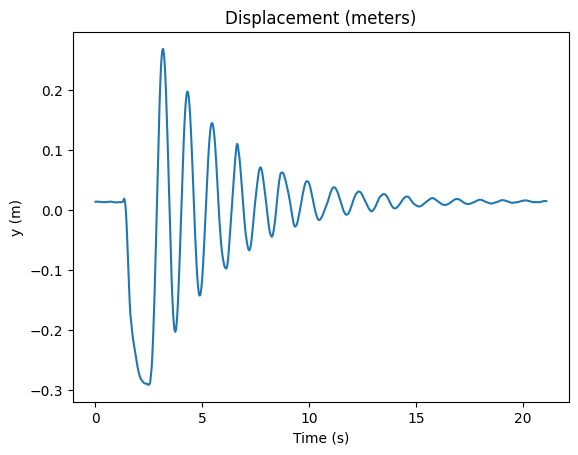

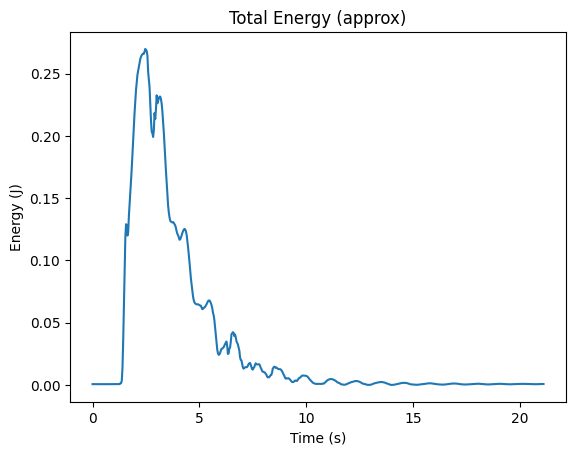

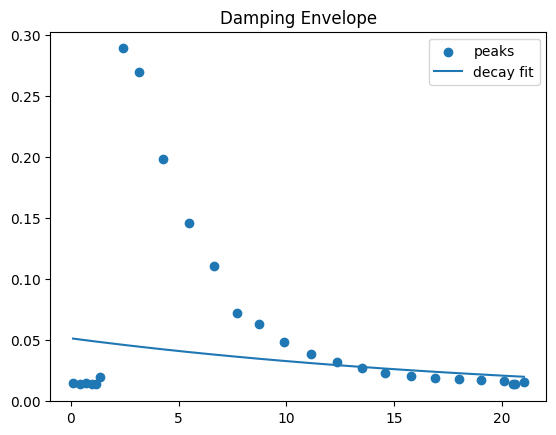

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# -------------------------
# INPUTS (YOU MUST SET THESE)
# -------------------------
centers = np.array(centers)

fps = 30

# Known physical calibration (YOU MUST PROVIDE THIS)
# Example: length of object in real life
known_length_m = 0.1
known_length_pixels = 100  # measure once from frame

meters_per_pixel = known_length_m / known_length_pixels

# Mass of object (YOU MUST KNOW OR ASSUME)
m = 0.2  # kg

# -------------------------
# TIME
# -------------------------
t = np.arange(len(centers)) / fps

# -------------------------
# POSITION (CONVERT TO METERS)
# -------------------------
x = centers[:, 0] * meters_per_pixel
y = -centers[:, 1] * meters_per_pixel  # flip axis

# -------------------------
# SMOOTH SIGNAL
# -------------------------
y_smooth = savgol_filter(y, window_length=11, polyorder=3)

# remove offset
y0 = y_smooth - np.mean(y_smooth)

# -------------------------
# VELOCITY & ACCELERATION
# -------------------------
dt = 1 / fps
v = np.gradient(y0, dt)
a = np.gradient(v, dt)

# -------------------------
# FIND NATURAL FREQUENCY (FFT)
# -------------------------
fft = np.fft.fft(y0)
freqs = np.fft.fftfreq(len(y0), d=dt)

mask = freqs > 0
dominant_freq = freqs[mask][np.argmax(np.abs(fft[mask]))]

omega = 2 * np.pi * dominant_freq

# -------------------------
# DAMPING (LOG DECAY)
# -------------------------
peaks_t = []
peaks_y = []

for i in range(1, len(y0) - 1):
    if y0[i] > y0[i-1] and y0[i] > y0[i+1]:
        peaks_t.append(t[i])
        peaks_y.append(abs(y0[i]))

peaks_t = np.array(peaks_t)
peaks_y = np.array(peaks_y)

log_amp = np.log(peaks_y + 1e-8)

gamma = -np.polyfit(peaks_t, log_amp, 1)[0]

# -------------------------
# SPRING CONSTANT
# k = m * omega^2
# -------------------------
k = m * omega**2

# -------------------------
# ENERGY
# -------------------------
KE = 0.5 * m * v**2

# approximate total energy envelope
E_total = KE + 0.5 * k * y0**2

# -------------------------
# RESULTS
# -------------------------
print("PHYSICAL PARAMETERS")
print("-------------------")
print("ω (rad/s):", omega)
print("γ (damping):", gamma)
print("Spring constant k (N/m):", k)

print("\nENERGY")
print("Avg KE:", np.mean(KE))
print("Avg total energy:", np.mean(E_total))

# -------------------------
# PLOTS
# -------------------------
plt.figure()
plt.plot(t, y0)
plt.title("Displacement (meters)")
plt.xlabel("Time (s)")
plt.ylabel("y (m)")
plt.show()

plt.figure()
plt.plot(t, E_total)
plt.title("Total Energy (approx)")
plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.show()

plt.figure()
plt.scatter(peaks_t, peaks_y, label="peaks")
plt.plot(peaks_t, np.exp(np.polyval(np.polyfit(peaks_t, log_amp, 1), peaks_t)),
         label="decay fit")
plt.title("Damping Envelope")
plt.legend()
plt.show()

In [5]:
import numpy as np
from scipy.signal import savgol_filter

# -------------------------
# INPUT DATA
# -------------------------
centers = np.array(centers)

fps = 30
dt = 1 / fps

# -------------------------
# POSITION (spring motion axis)
# -------------------------
y = -centers[:, 1]  # flip image axis

# -------------------------
# SMOOTH SIGNAL
# -------------------------
y = savgol_filter(y, 11, 3)

# remove offset
y = y - np.mean(y)

t = np.arange(len(y)) * dt

# -------------------------
# VELOCITY
# -------------------------
v = np.gradient(y, dt)

# -------------------------
# NATURAL FREQUENCY (ω)
# -------------------------
fft = np.fft.fft(y)
freqs = np.fft.fftfreq(len(y), d=dt)

mask = freqs > 0
dominant_freq = freqs[mask][np.argmax(np.abs(fft[mask]))]

omega = 2 * np.pi * dominant_freq

# -------------------------
# DAMPING (γ) from peak decay
# -------------------------
peaks_t = []
peaks_y = []

for i in range(1, len(y)-1):
    if y[i] > y[i-1] and y[i] > y[i+1]:
        peaks_t.append(t[i])
        peaks_y.append(abs(y[i]))

peaks_t = np.array(peaks_t)
peaks_y = np.array(peaks_y)

log_amp = np.log(peaks_y + 1e-8)

gamma = -np.polyfit(peaks_t, log_amp, 1)[0]

# -------------------------
# SPRING CONSTANT k
# k = m * ω²  (YOU MUST SET MASS)
# -------------------------
m = 0.2  # kg (change this)
k = m * omega**2

# -------------------------
# OUTPUT
# -------------------------
print("RESULTS")
print("--------")
print("ω (rad/s):", omega)
print("γ (damping):", gamma)
print("k (N/m):", k)

RESULTS
--------
ω (rad/s): 5.648920544309723
γ (damping): 0.045236262186352974
k (N/m): 6.382060663184892
